# Análisis de datos - TP Final

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import kagglehub
from scipy import stats as st
from scipy.stats import describe

In [4]:
pd.options.display.float_format = '{:,.4f}'.format

## Exploración y comprensión de los datos (Joni)

### Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos.

In [5]:
# Download latest version
path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

print("Path to dataset files:", path)

100%|████████████████████████████████████████| 240M/240M [00:17<00:00, 14.0MB/s]

Extracting files...


Path to dataset files: /home/alan/.cache/kagglehub/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/versions/905


In [8]:
df = pd.read_csv(path + "/TMDB_movie_dataset_v11.csv", na_values='sin especificar', encoding='ISO-8859-1')
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.3640,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.4170,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.5120,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.5730,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.7100,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [9]:
df.shape

(1402844, 24)

In [10]:
df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='str')

In [11]:
df.head(5)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.3640,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.4170,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.5120,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.5730,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.7100,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


### Describir las características principales del dataset, incluyendo el número de observaciones, número de variables y tipos de datos.


In [12]:
# Tipo por columna.
df.dtypes.to_frame("dtype")

,dtype
id,int64
title,str
vote_average,float64
vote_count,int64
status,str
release_date,str
revenue,int64
runtime,int64
adult,bool
backdrop_path,str


In [13]:
df['vote_average'].describe()

count   1,402,844.0000
mean            1.5707
std             2.8667
min             0.0000
25%             0.0000
50%             0.0000
75%             1.5000
max            10.0000
Name: vote_average, dtype: float64

In [14]:
df['vote_count'].describe()

count   1,402,844.0000
mean           15.2955
std           286.7968
min             0.0000
25%             0.0000
50%             0.0000
75%             1.0000
max        34,495.0000
Name: vote_count, dtype: float64

In [15]:
df['status'].unique()

<StringArray>
[       'Released',         'Planned', 'Post Production',   'In Production',
         'Rumored',        'Canceled']
Length: 6, dtype: str

In [16]:
pd.to_datetime(df['release_date'], errors='coerce').max()

Timestamp('2099-12-31 00:00:00')

In [17]:
pd.to_datetime(df['release_date'], errors='coerce').min()

Timestamp('1800-01-01 00:00:00')

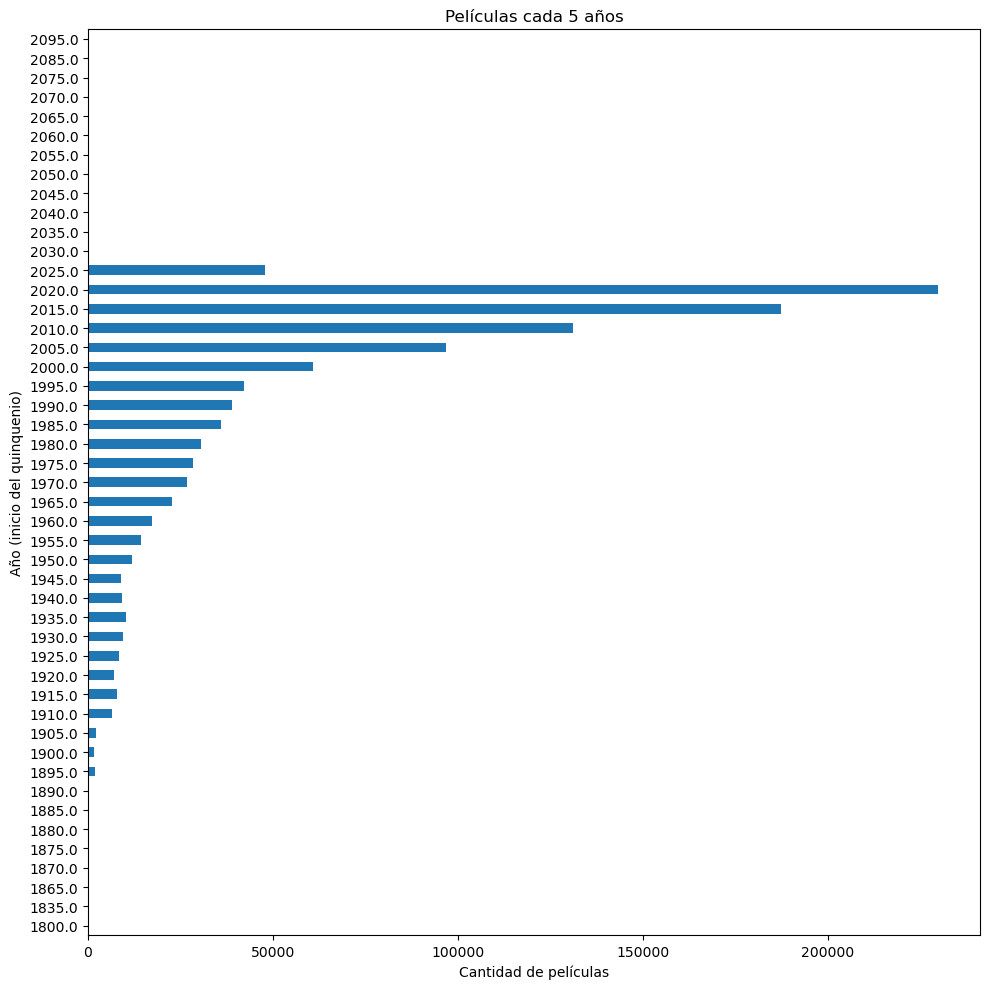

In [18]:
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year.dropna().astype(int)
df['quinquenio'] = (df['year'] // 5) * 5   # 1992→1990, 1997→1995, 2003→2000
peliculas_por_5_anos = df['quinquenio'].value_counts().sort_index()
peliculas_por_5_anos.plot(kind='barh', figsize=(10, 10))
plt.xlabel('Cantidad de películas')
plt.ylabel('Año (inicio del quinquenio)')
plt.title('Películas cada 5 años')
plt.tight_layout()
plt.show()

In [19]:
df['revenue'].describe()

count       1,402,844.0000
mean          621,394.5272
std        19,169,384.5567
min               -12.0000
25%                 0.0000
50%                 0.0000
75%                 0.0000
max     4,999,999,999.0000
Name: revenue, dtype: float64

In [20]:
df['runtime'].describe()

count   1,402,844.0000
mean           44.1693
std            60.7042
min           -28.0000
25%             0.0000
50%            16.0000
75%            85.0000
max        14,400.0000
Name: runtime, dtype: float64

In [21]:
df['adult'].unique()

array([False,  True])

In [22]:
df['budget'].describe()

count     1,402,844.0000
mean        237,271.7262
std       5,077,264.8619
min               0.0000
25%               0.0000
50%               0.0000
75%               0.0000
max     999,999,999.0000
Name: budget, dtype: float64

In [23]:
df['original_language'].unique()

<StringArray>
['en', 'ko', 'fr', 'ja', 'it', 'es', 'pl', 'pt', 'hi', 'tr',
 ...
 'ki', 'ce', 'aa', 'ee', 'gv', 'an', 'rn', 'ii', 'ts', 'kg']
Length: 177, dtype: str

In [24]:
df['popularity'].describe()

count   1,402,844.0000
mean            1.0230
std             6.8447
min             0.0000
25%             0.0714
50%             0.6000
75%             0.7130
max         2,994.3570
Name: popularity, dtype: float64

In [25]:
df['tagline'].head()

0                 Your mind is the scene of the crime.
1    Mankind was born on Earth. It was never meant ...
2                    Welcome to a world without rules.
3                          Enter the world of Pandora.
4                              Some assembly required.
Name: tagline, dtype: str

In [26]:
sorted(
    df['genres']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

['Action',
 'Adventure',
 'Animation',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'History',
 'Horror',
 'Music',
 'Mystery',
 'Romance',
 'Science Fiction',
 'TV Movie',
 'Thriller',
 'War',
 'Western']

In [27]:
production_companies = sorted(
    df['production_companies']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

production_companies

['',
 '"A ME AND YOU MOTION PICTURE"',
 '"Creo" of M. Bystritsky',
 '"DIA" Productions GmbH & Co. KG',
 '"Dann Moss Entertainment',
 '"En TeorÃ\xada" Producciones',
 '"Film Company "Karbush"',
 '"Filma" Shareholders\' Association',
 '"G" P.C. S.A.',
 '"GREEN" Productions',
 '"Hanochi" Film Partners',
 '"Haruka\'s Pottery" Film Partners',
 '"Hypnosis Mic - Division Rap Battle" Rule the Stage Production Committee',
 '"I Used To Fuck People Like You In Prison" Records',
 '"It Goes to 11" Productions',
 '"Just The Filter" Productions',
 '"M" Films',
 '"MIYAGINO" Film Partners',
 '"Mega" Marbella Entertainment Groups & Artists',
 '"N" Film Studio',
 '"Shine kino" studio',
 '"Srcem za djecu" Sarajevo',
 '"Step" Ltd KinoÅ\x9firkÉ\x99ti',
 '"Swaying Mariko" Film Production Committee',
 '"TOKYO Ainu" Film Production Committee',
 '"The Mountain" Production Committee',
 '"Virtuoz" TRK',
 '"Weathering With You" Film Partners',
 '"Yeni Film" Film Company',
 '"unknown" estudios',
 '"á\x83¥á\x83\x90á

In [28]:
len(production_companies)

187874

In [29]:
production_countries = sorted(
    df['production_countries']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

production_countries

['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antarctica',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Bouvet Island',
 'Brazil',
 'British Indian Ocean Territory',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burma',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Christmas Island',
 'Cocos  Islands',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 "Cote D'Ivoire",
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Czechoslovakia',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Germany',
 'East Timor',
 'Ecuador',
 'Egypt',
 'El Salvador

In [30]:
len(production_countries)

250

In [31]:
spoken_languages = sorted(
    df['spoken_languages']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

spoken_languages

['Abkhazian',
 'Afar',
 'Afrikaans',
 'Akan',
 'Albanian',
 'Amharic',
 'Arabic',
 'Aragonese',
 'Armenian',
 'Assamese',
 'Avaric',
 'Avestan',
 'Aymara',
 'Azerbaijani',
 'Bambara',
 'Bashkir',
 'Basque',
 'Belarusian',
 'Bengali',
 'Bislama',
 'Bosnian',
 'Breton',
 'Bulgarian',
 'Burmese',
 'Cantonese',
 'Catalan',
 'Chamorro',
 'Chechen',
 'Chichewa; Nyanja',
 'Chuvash',
 'Cornish',
 'Corsican',
 'Cree',
 'Croatian',
 'Czech',
 'Danish',
 'Divehi',
 'Dutch',
 'Dzongkha',
 'English',
 'Esperanto',
 'Estonian',
 'Ewe',
 'Faroese',
 'Fijian',
 'Finnish',
 'French',
 'Frisian',
 'Fulah',
 'Gaelic',
 'Galician',
 'Ganda',
 'Georgian',
 'German',
 'Greek',
 'Guarani',
 'Gujarati',
 'Haitian; Haitian Creole',
 'Hausa',
 'Hebrew',
 'Herero',
 'Hindi',
 'Hiri Motu',
 'Hungarian',
 'Icelandic',
 'Ido',
 'Igbo',
 'Indonesian',
 'Interlingua',
 'Interlingue',
 'Inuktitut',
 'Inupiaq',
 'Irish',
 'Italian',
 'Japanese',
 'Javanese',
 'Kalaallisut',
 'Kannada',
 'Kanuri',
 'Kashmiri',
 'Kazakh'

In [32]:
len(spoken_languages)

186

In [33]:
keywords = sorted(
    df['keywords']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

keywords

['',
 '"me escanee el ojo',
 '"on the "brink of death"',
 '"on the brink of death"',
 '"robin hood" thieves',
 '"spider" john koerner',
 '"the dunce" series',
 '"where every choice changes your life."',
 '"à¶\x85à¶´à·\x92 à¶¶à¶½à·\x8aà¶½à·\x9d à·\x80à¶\x9cà·\x9a à¶\x9aà·\x8fà¶\x9cà¶±à·\x8aà¶±à·\x80à·\x8f à·\x83à¶»à·\x8a à¶´à·\x9cà¶©à·\x92 à¶¸à·\x83à·\x8aà¶\x9aà¶§à·\x8aà¶§à¶\x9aà¶§"',
 '#',
 '#bobimovie',
 '#brazilianblackmusic',
 '#comedy #gangsters #fantasy #lawofattraction #funny #release #uk #usa #love #evil #guns #humor #anotherexcellentday #guyritchie #snatch #quentintarantino #trainspotting',
 '#deliveranceshortfilm',
 '#finalclash',
 '#lauterwerden',
 '#likeme',
 '#loveoverwealth',
 '#milamovie',
 '#mute',
 '#nghesieude',
 '#nsd',
 '#parisfashion #sexygirlstyle #parisstreetstyle #frenchfashionvibes #gothfashion #y2kstyle #darkaesthetic #streetwearvibes #edgystyle #artsylook',
 '#raffyhdz',
 '#tahilsumkan',
 '#terremoto',
 '#tipmuskan',
 '#tubeclash',
 '#walktalk',
 '#yeahhh',
 "

In [34]:
len(keywords)

69042

In [35]:
# Contar la cantidad de valores nulos en cada columna
df.isna().sum()  

id                            0
title                        18
vote_average                  0
vote_count                    0
status                        0
release_date             306881
revenue                       0
runtime                       0
adult                         0
backdrop_path           1052902
budget                        0
homepage                1258298
imdb_id                  737938
original_language             0
original_title               18
overview                 320603
popularity                    0
poster_path              495110
tagline                 1207469
genres                   613360
production_companies     803373
production_countries     675619
spoken_languages         648632
keywords                1054288
year                     306881
quinquenio               306881
dtype: int64

In [36]:
# Calcular la proporción de valores nulos en cada columna
df.isna().mean().round(4)*100

id                      0.0000
title                   0.0000
vote_average            0.0000
vote_count              0.0000
status                  0.0000
release_date           21.8800
revenue                 0.0000
runtime                 0.0000
adult                   0.0000
backdrop_path          75.0500
budget                  0.0000
homepage               89.7000
imdb_id                52.6000
original_language       0.0000
original_title          0.0000
overview               22.8500
popularity              0.0000
poster_path            35.2900
tagline                86.0700
genres                 43.7200
production_companies   57.2700
production_countries   48.1600
spoken_languages       46.2400
keywords               75.1500
year                   21.8800
quinquenio             21.8800
dtype: float64

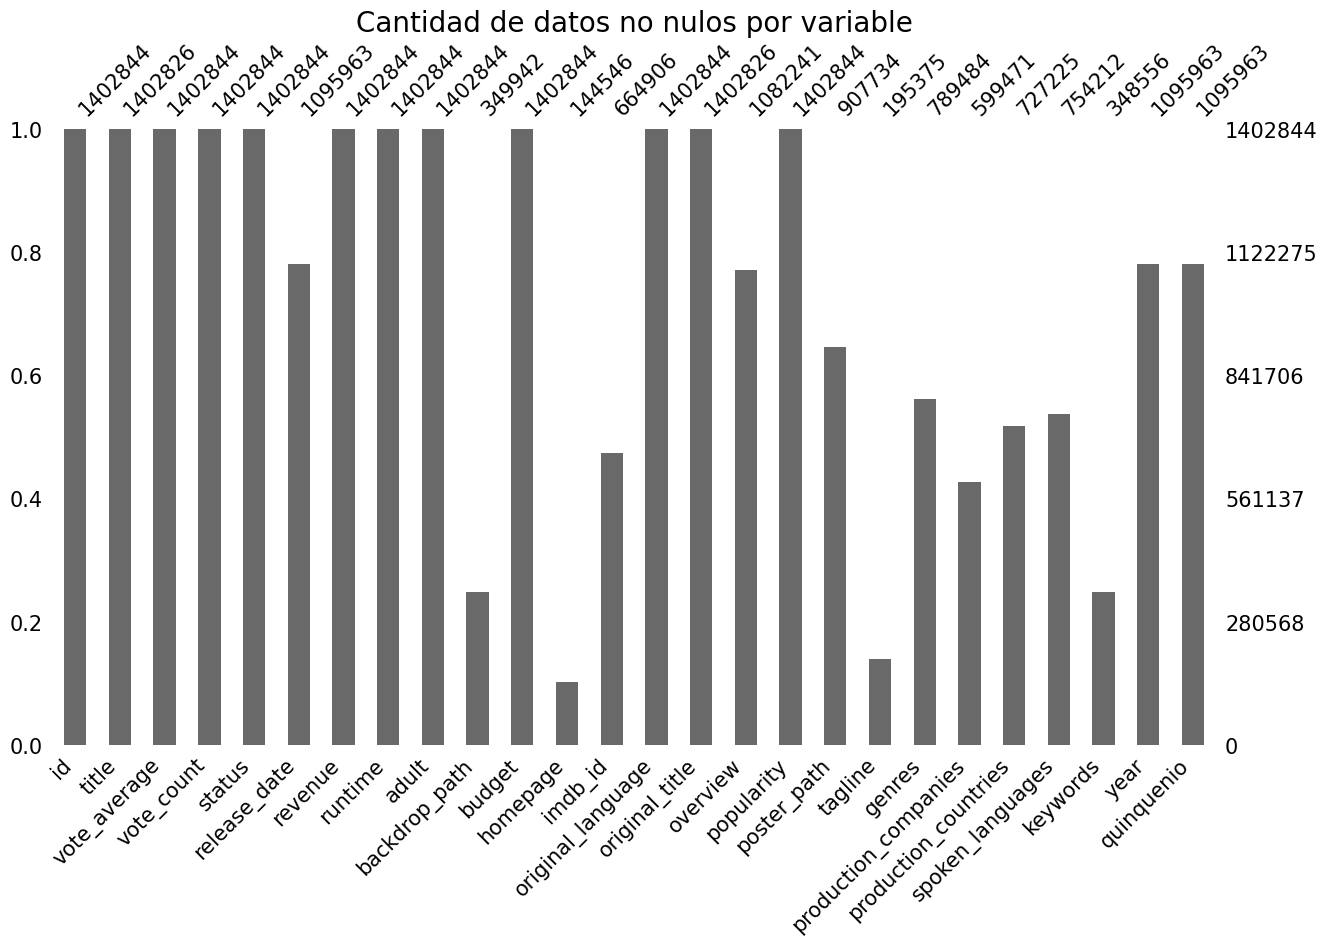

In [37]:
msno.bar(df, fontsize=15, figsize=(15,8))
plt.title("Cantidad de datos no nulos por variable", fontsize=20)
plt.show()

<Axes: >

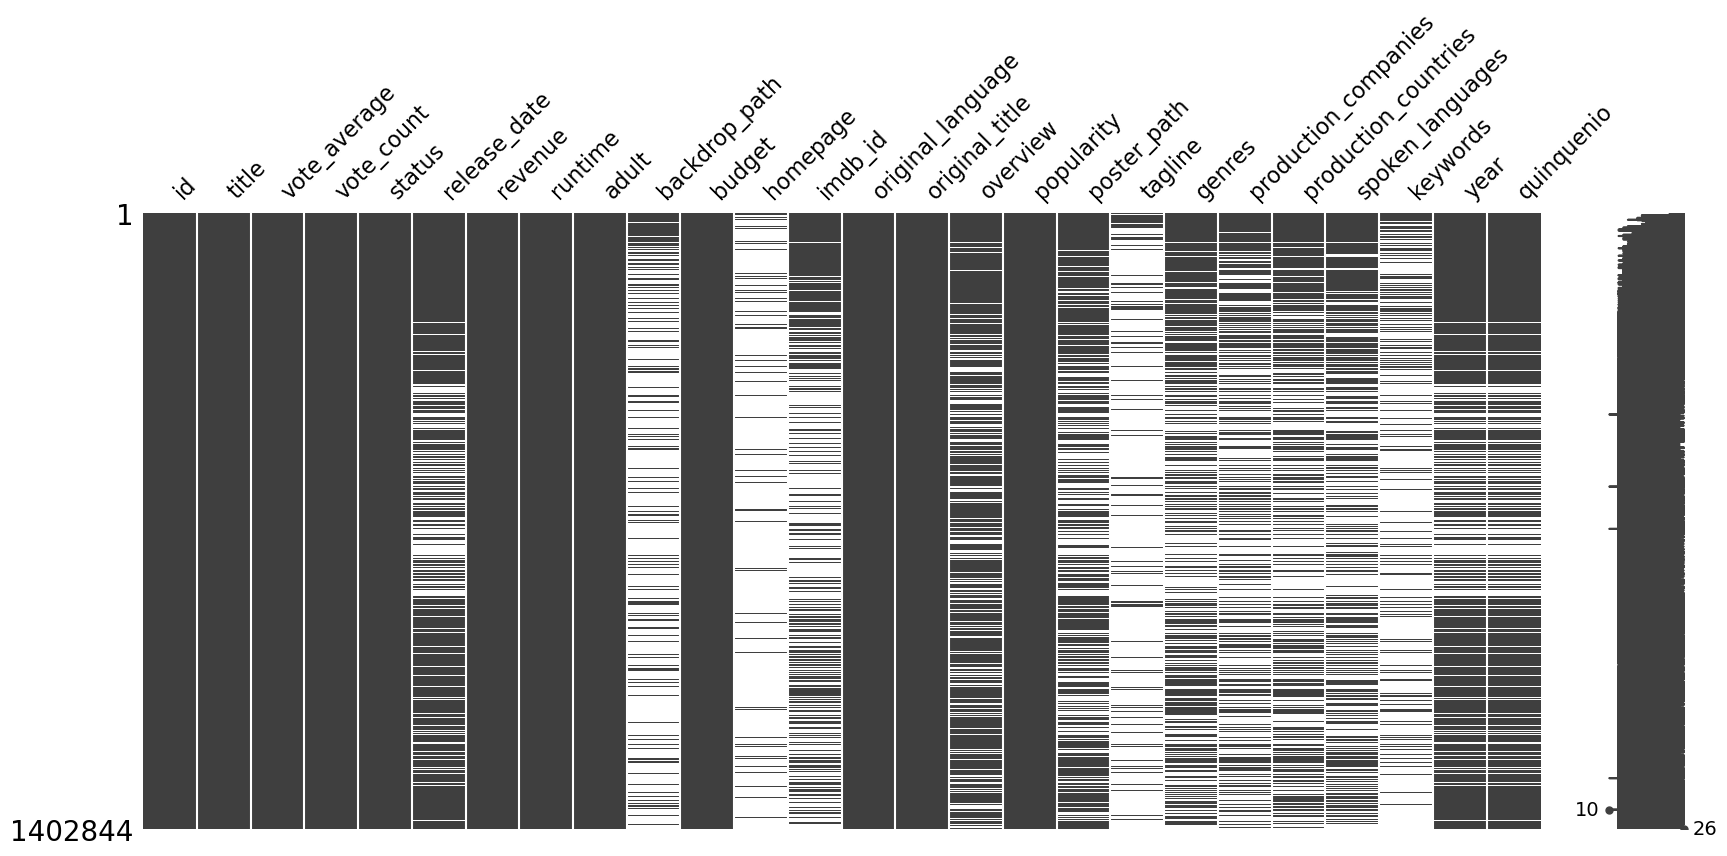

In [38]:
# Matriz de valores faltantes
msno.matrix(df, figsize=(20,8))

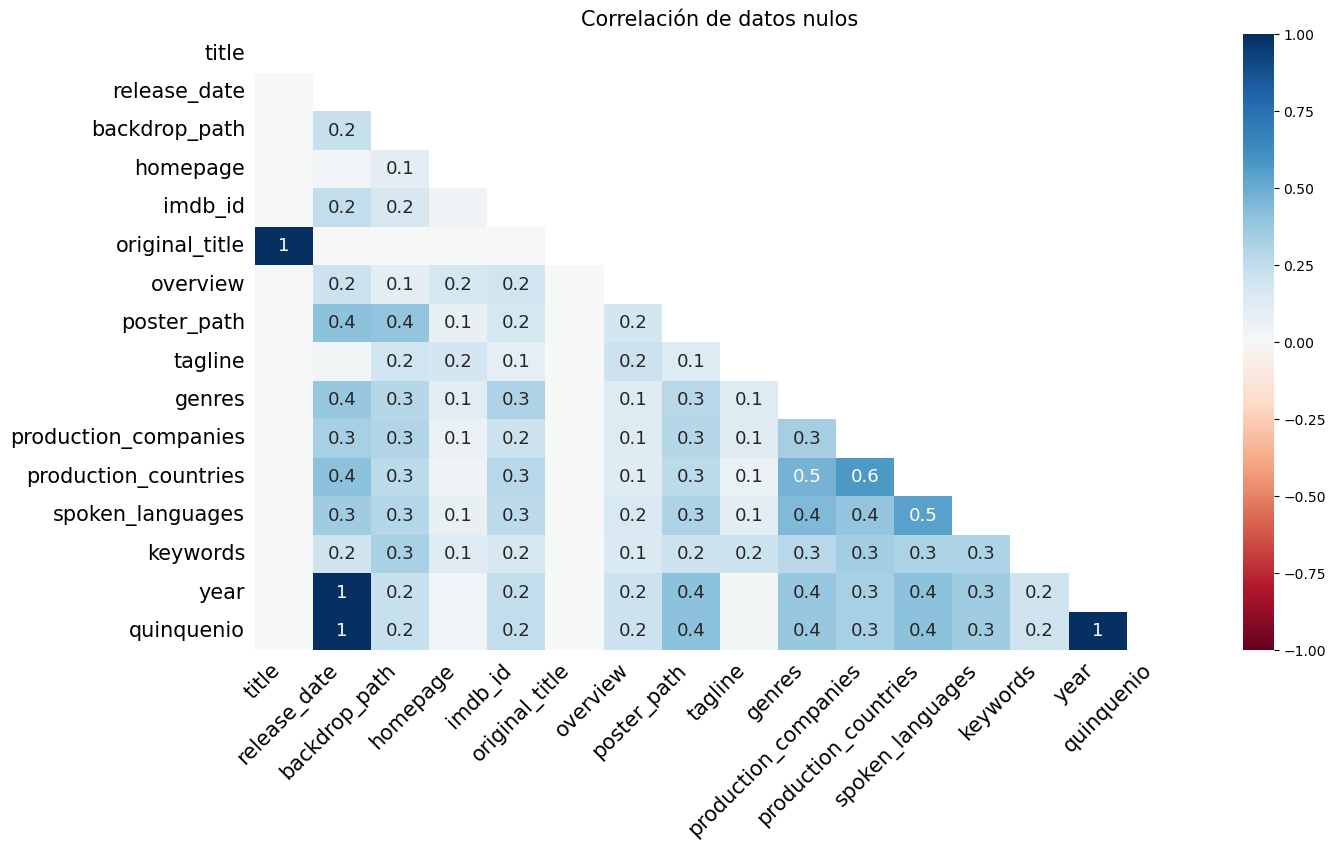

In [39]:
msno.heatmap(df, fontsize=15, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)
plt.show()

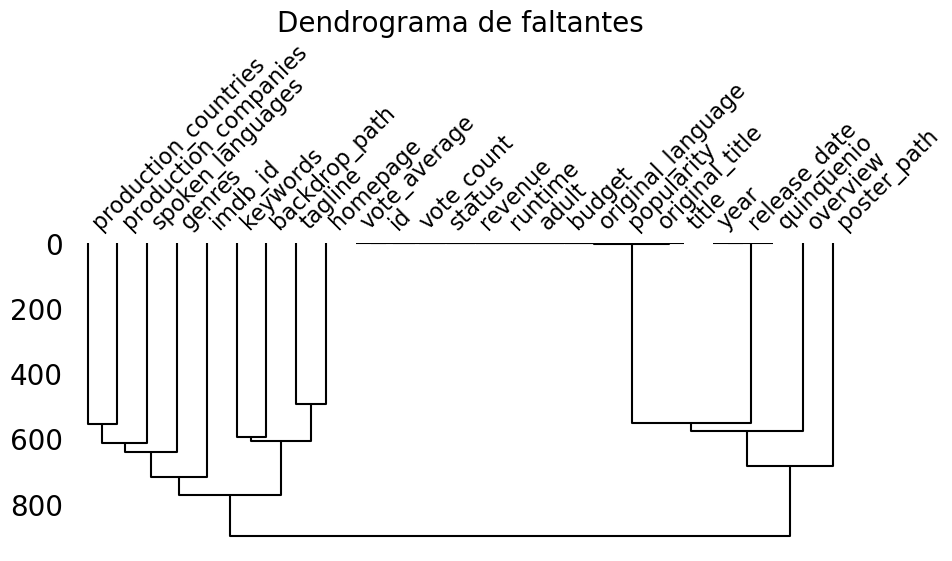

In [40]:
msno.dendrogram(df, figsize=(10,4))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

### Identificar patrones generales y distribuciones.


In [41]:
# Distribución de variables numéricas: estadísticos y rangos.
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,"1,402,844.0000","890,186.4764","472,937.6600",2.0000,"489,950.7500","912,687.5000","1,304,670.2500","1,669,313.0000"
vote_average,"1,402,844.0000",1.5707,2.8667,0.0000,0.0000,0.0000,1.5000,10.0000
vote_count,"1,402,844.0000",15.2955,286.7968,0.0000,0.0000,0.0000,1.0000,"34,495.0000"
revenue,"1,402,844.0000","621,394.5272","19,169,384.5567",-12.0000,0.0000,0.0000,0.0000,"4,999,999,999.0000"
runtime,"1,402,844.0000",44.1693,60.7042,-28.0000,0.0000,16.0000,85.0000,"14,400.0000"
budget,"1,402,844.0000","237,271.7262","5,077,264.8619",0.0000,0.0000,0.0000,0.0000,"999,999,999.0000"
popularity,"1,402,844.0000",1.0230,6.8447,0.0000,0.0714,0.6000,0.7130,"2,994.3570"
year,"1,095,963.0000","2,001.1110",26.4800,"1,800.0000","1,991.0000","2,012.0000","2,020.0000","2,099.0000"
quinquenio,"1,095,963.0000","1,999.1066",26.5144,"1,800.0000","1,990.0000","2,010.0000","2,020.0000","2,095.0000"


**Variables numéricas continuas** — Un gráfico por celda. Donde hay muchos ceros, se excluyen y/o se usa `log1p` (ingresos, presupuesto, conteos, etc.).


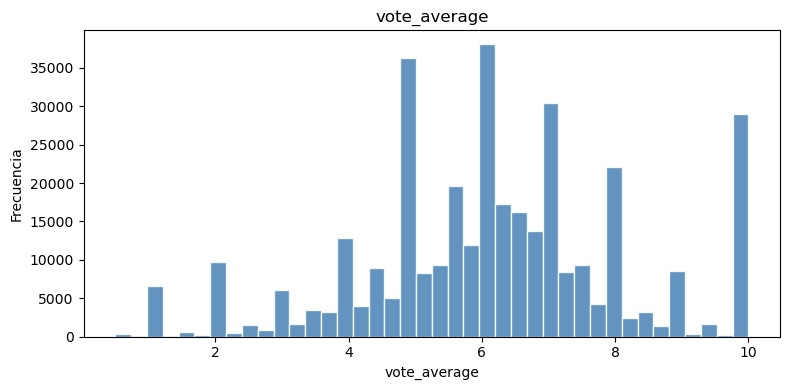

In [42]:
# vote_average (solo 0 < x ≤ 10; excluye promedios en 0)
col = "vote_average"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[(s > 0) & (s <= 10)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(s_plot, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel("vote_average")
ax.set_ylabel("Frecuencia")
ax.set_title(f"vote_average")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


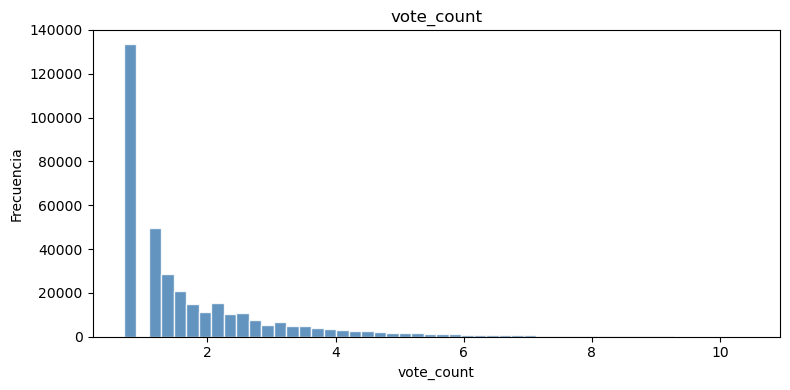

In [43]:
# vote_count (log1p; excluye ceros)
col = "vote_count"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(col)
ax.set_ylabel("Frecuencia")
ax.set_title("vote_count")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


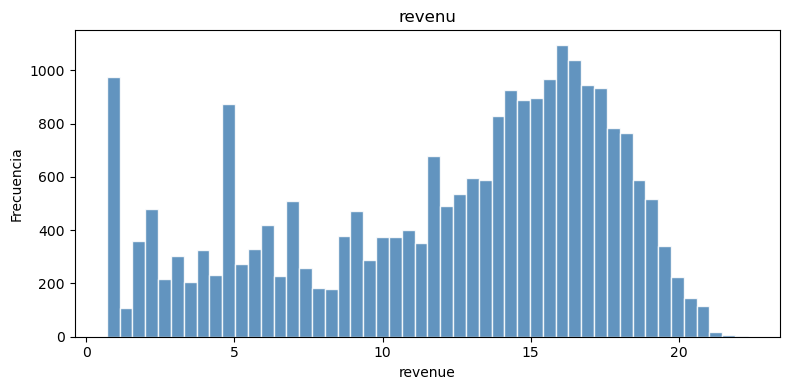

In [44]:
# revenue (log1p; excluye ceros)
col = "revenue"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(f"{col}")
ax.set_ylabel("Frecuencia")
ax.set_title(f"revenu")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


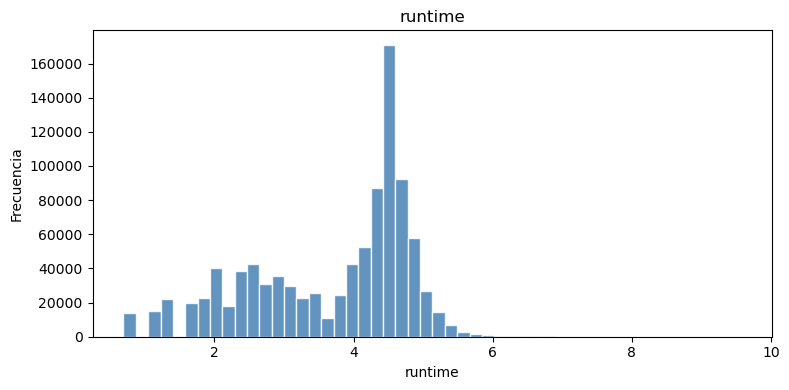

In [45]:
# runtime (log1p; excluye ceros)
col = "runtime"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(col)
ax.set_ylabel("Frecuencia")
ax.set_title("runtime")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


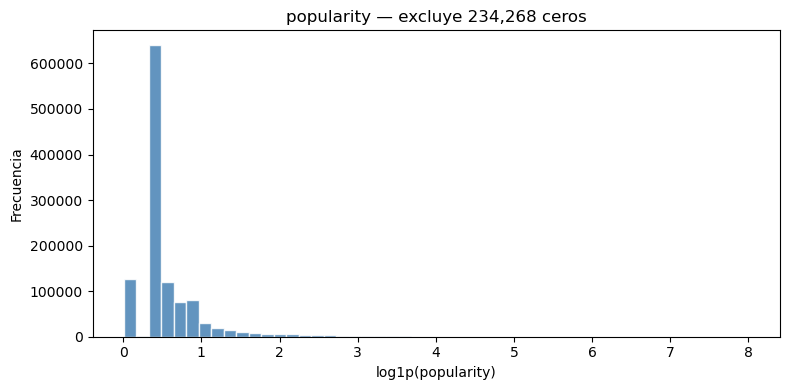

In [46]:
# popularity (log1p; excluye ceros)
col = "popularity"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(f"log1p({col})")
ax.set_ylabel("Frecuencia")
ax.set_title(f"popularity — excluye {n0:,} ceros")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


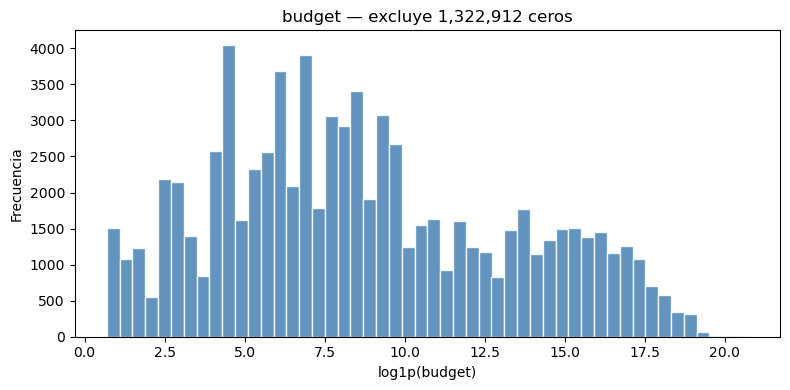

In [47]:
# budget (log1p; excluye ceros — mismo patrón que revenue)
col = "budget"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(f"log1p({col})")
ax.set_ylabel("Frecuencia")
ax.set_title(f"budget — excluye {n0:,} ceros")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


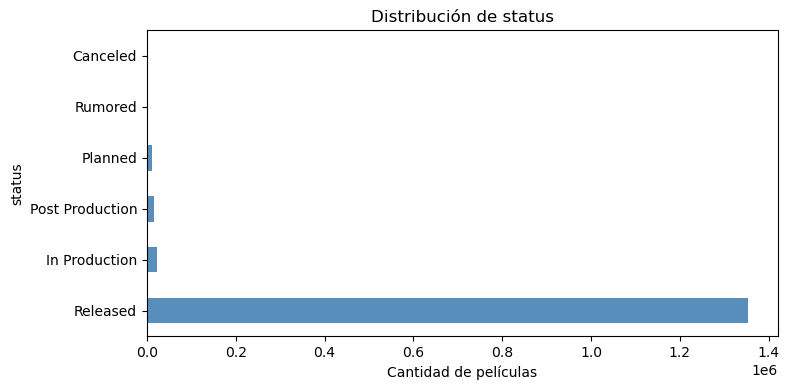

In [48]:
# status (categórica)
vc = df["status"].value_counts(dropna=False)
fig, ax = plt.subplots(figsize=(8, 4))
vc.plot(kind="barh", ax=ax, color="steelblue", alpha=0.9)
ax.set_xlabel("Cantidad de películas")
ax.set_title("Distribución de status")
plt.tight_layout()
plt.show()


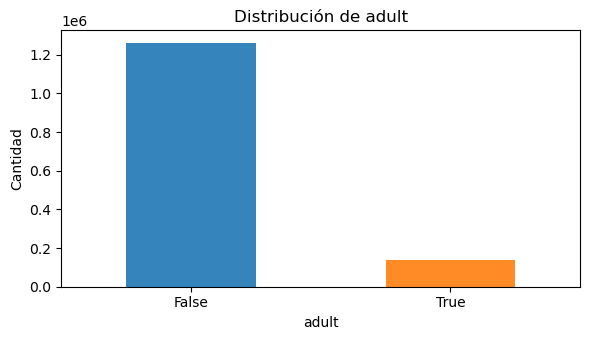

In [49]:
# adult (categórica binaria)
vc = df["adult"].value_counts(dropna=False)
fig, ax = plt.subplots(figsize=(6, 3.5))
vc.plot(kind="bar", ax=ax, color=["tab:blue", "tab:orange"], alpha=0.9, rot=0)
ax.set_ylabel("Cantidad")
ax.set_title("Distribución de adult")
plt.tight_layout()
plt.show()


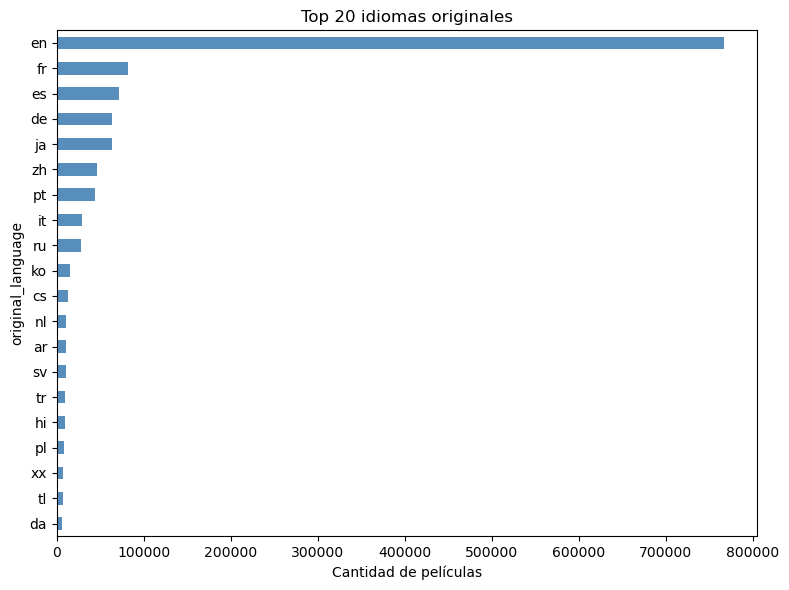

In [50]:
# original_language (top 20 idiomas)
vc = df["original_language"].fillna("(sin dato)").value_counts().head(20)
fig, ax = plt.subplots(figsize=(8, 6))
vc.sort_values().plot(kind="barh", ax=ax, color="steelblue", alpha=0.9)
ax.set_xlabel("Cantidad de películas")
ax.set_title("Top 20 idiomas originales")
plt.tight_layout()
plt.show()


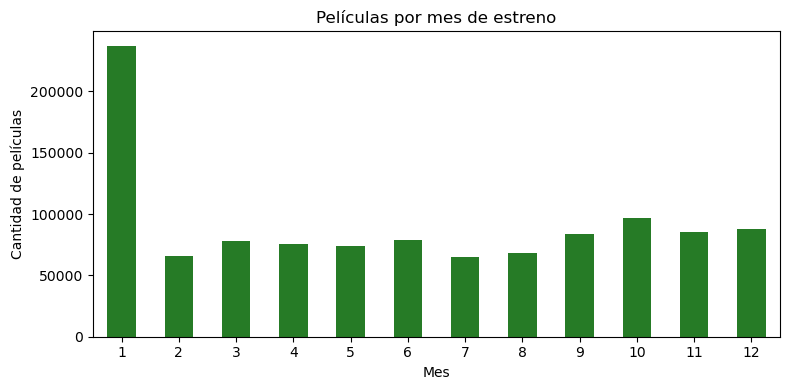

In [51]:
# Mes de estreno (1–12; desde release_date)
m = pd.to_datetime(df["release_date"], errors="coerce").dt.month.dropna().astype(int)
fig, ax = plt.subplots(figsize=(8, 4))
m.value_counts().sort_index().plot(kind="bar", ax=ax, color="darkgreen", alpha=0.85, rot=0)
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de películas")
ax.set_title("Películas por mes de estreno")
plt.tight_layout()
plt.show()


### Fecha de estreno (distribución temporal)


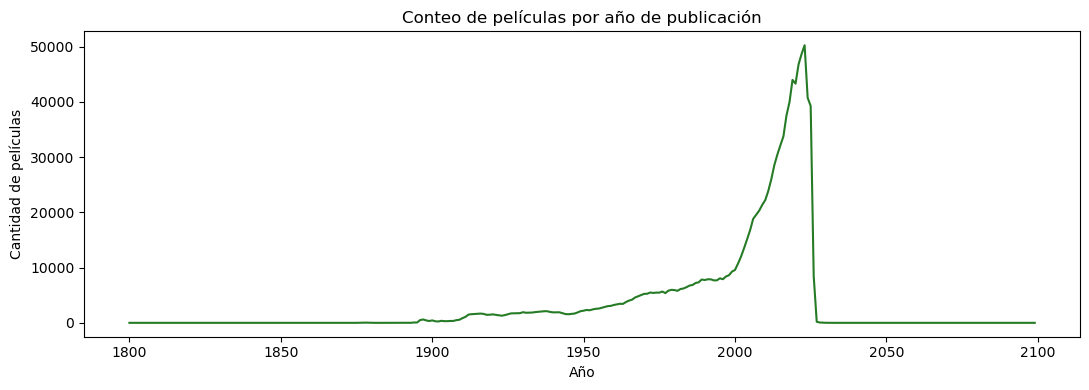

In [52]:
# Películas por año de estreno (patrón temporal).
years = pd.to_datetime(df["release_date"], errors="coerce").dt.year.dropna().astype(int)
ax = years.value_counts().sort_index().plot(figsize=(11, 4), color="darkgreen", alpha=0.85)
plt.xlabel("Año")
plt.ylabel("Cantidad de películas")
plt.title("Conteo de películas por año de publicación")
plt.tight_layout()
plt.show()


### Identificar errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR, MNAR).

In [53]:
# Valores faltantes por columna (conteo y % sobre el total de filas).
miss = df.isna().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
pd.DataFrame({"nulos": miss, "pct": miss_pct})[miss > 0]


,nulos,pct
homepage,1258298,89.7000
tagline,1207469,86.0700
keywords,1054288,75.1500
backdrop_path,1052902,75.0500
production_companies,803373,57.2700
imdb_id,737938,52.6000
production_countries,675619,48.1600
spoken_languages,648632,46.2400
genres,613360,43.7200
poster_path,495110,35.2900


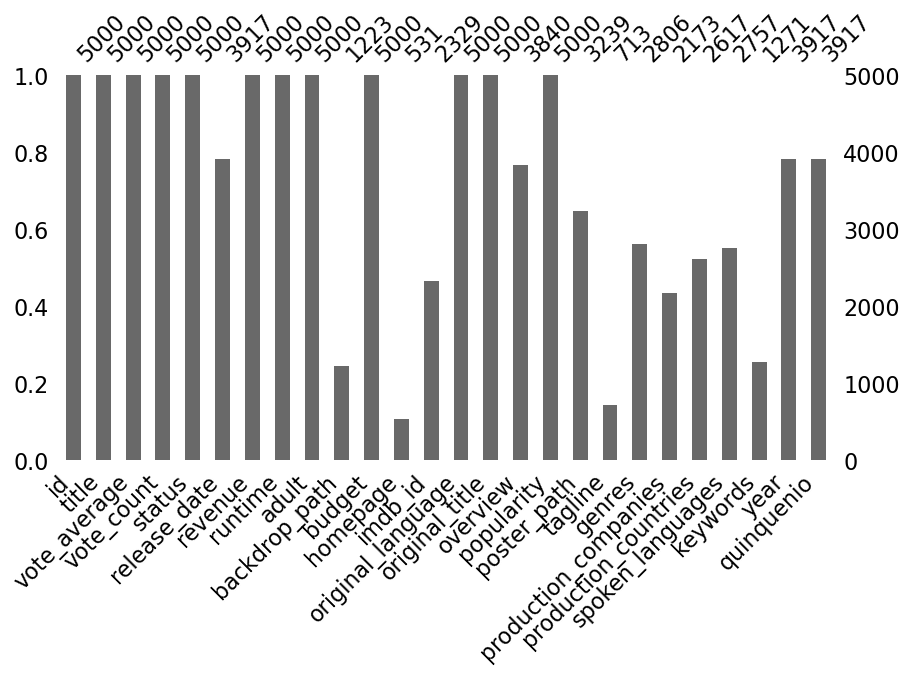

In [54]:
# Visualización de patrones de ausencia (missingno).
# Con muchas filas, una muestra conserva la forma del patrón de nulos.
_sample = df.sample(n=min(5000, len(df)), random_state=42)
msno.bar(_sample, figsize=(10, 5))
plt.show()


<Axes: >

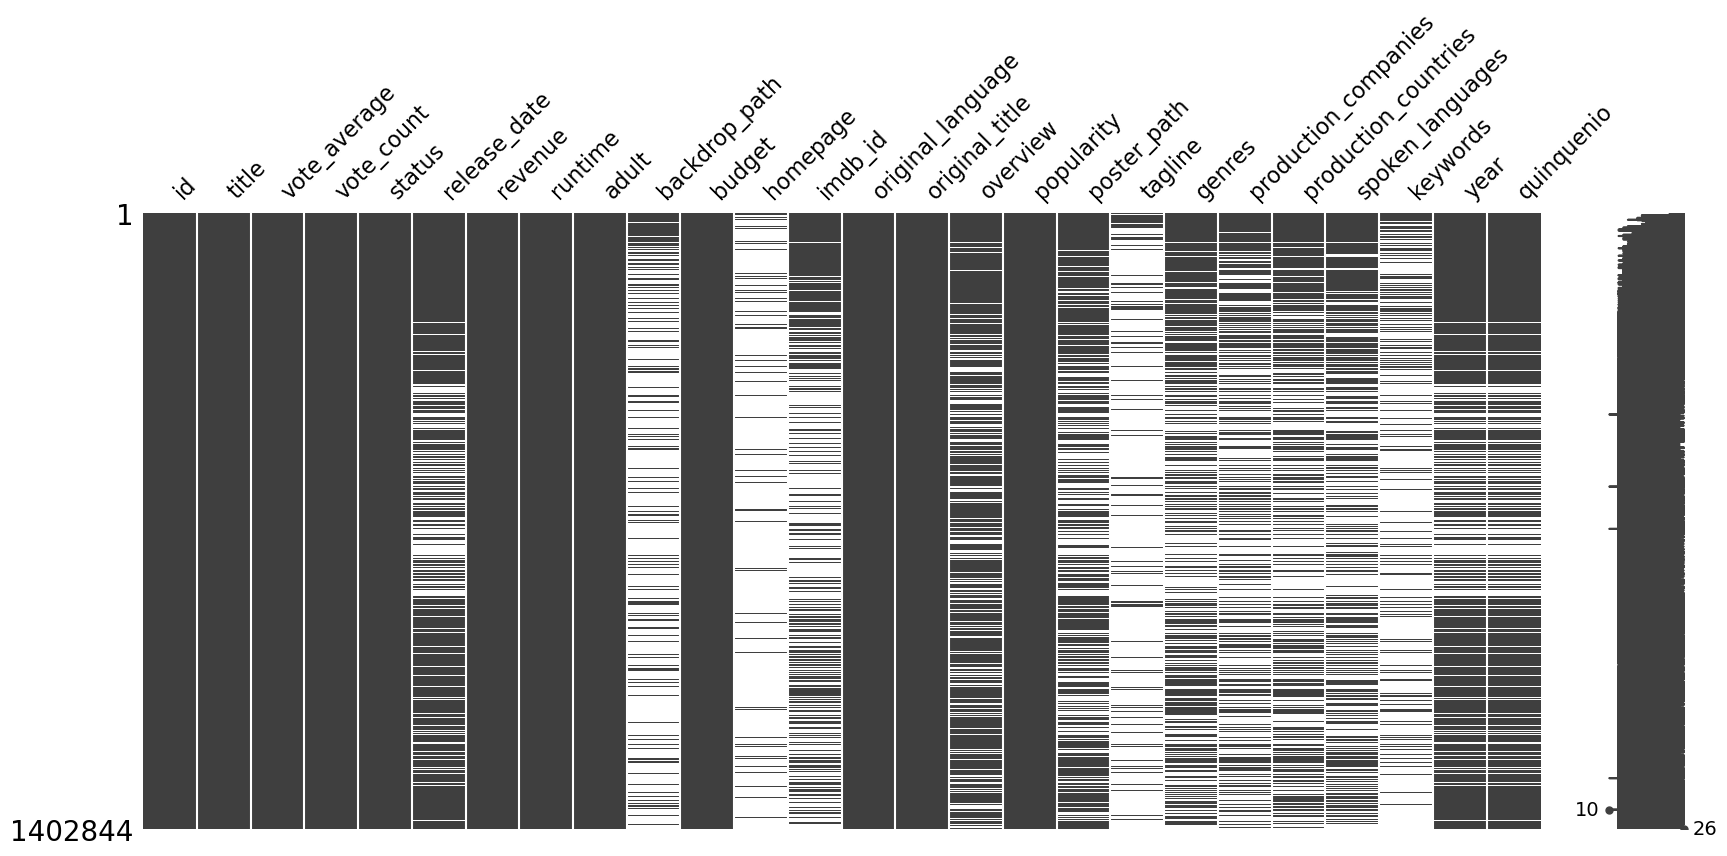

In [55]:
# Matriz de valores faltantes
msno.matrix(df, figsize=(20,8))

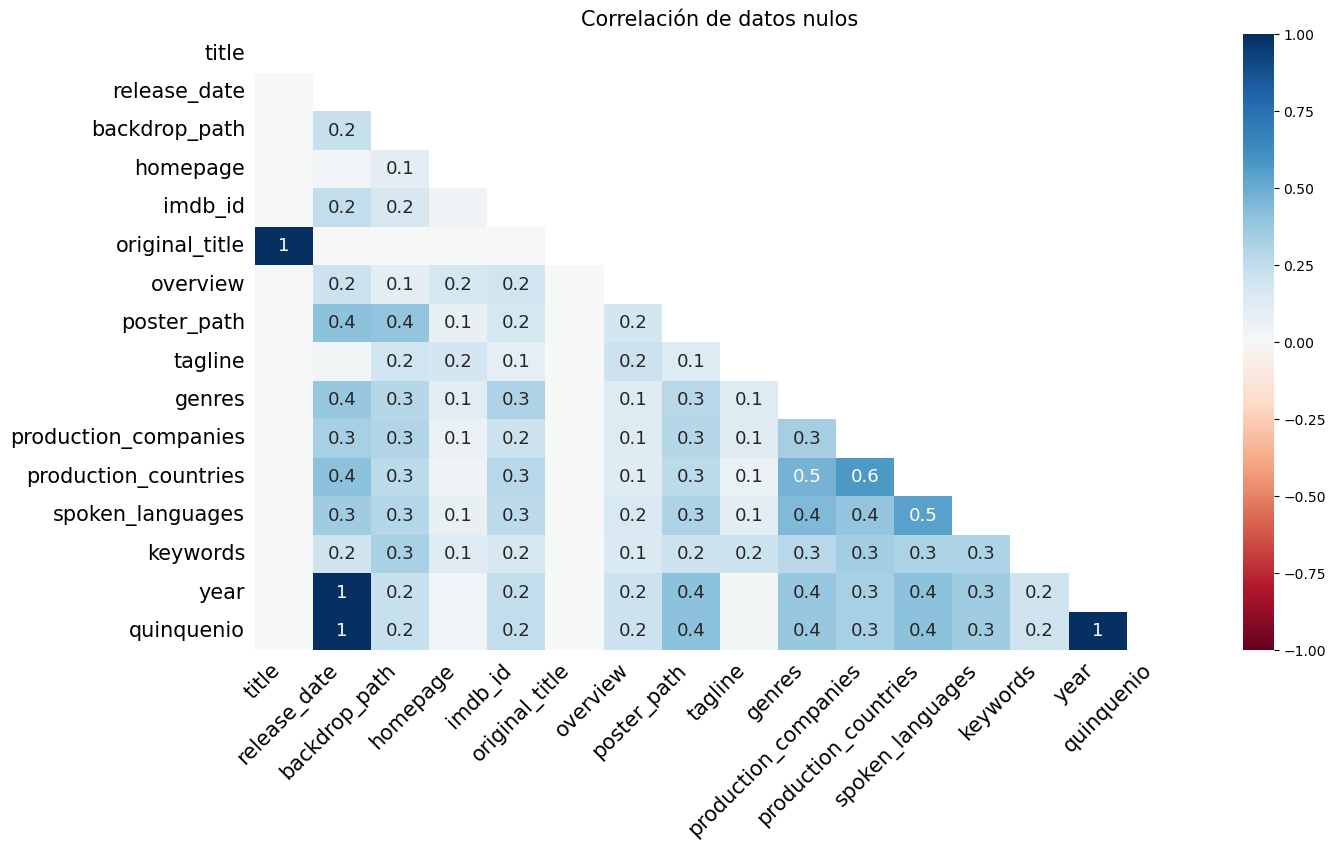

In [56]:
msno.heatmap(df, fontsize=15, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)
plt.show()

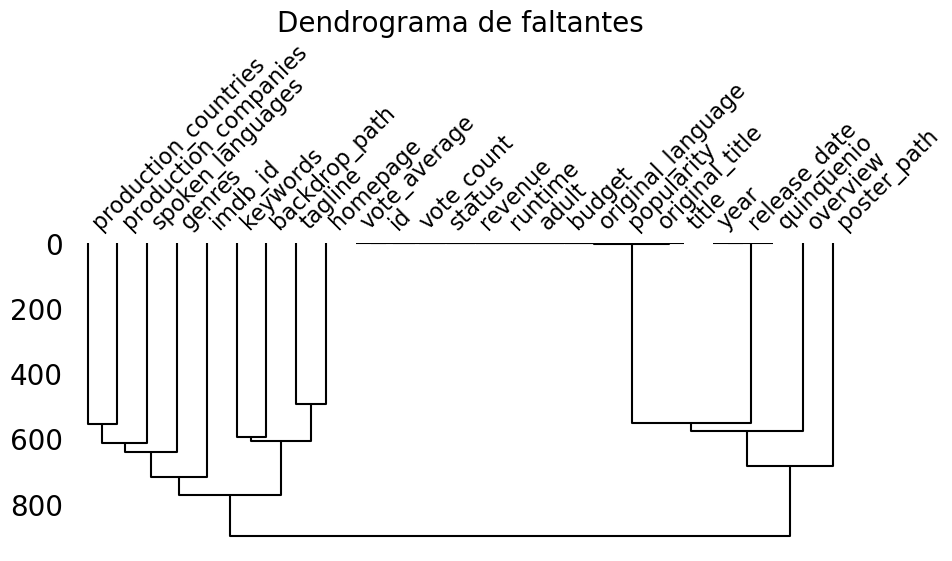

In [57]:
msno.dendrogram(df, figsize=(10,4))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

In [58]:
# Outliers: regla IQR (1.5×IQR) en todas las columnas numéricas.
# Se excluye `id` (identificador; los "outliers" no son interpretables como anomalías de negocio).
def iqr_outlier_pct(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) < 4:
        return len(s), np.nan, np.nan
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return len(s), 0, 0.0
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = (s < low) | (s > high)
    return len(s), int(out.sum()), 100 * out.mean()

num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "id"]
rows = []
for col in sorted(num_cols):
    n, n_out, pct = iqr_outlier_pct(df[col])
    rows.append({"columna": col, "n_validos": n, "n_outliers_IQR": n_out, "pct_outliers": pct})
display(pd.DataFrame(rows).sort_values("columna").reset_index(drop=True))


,columna,n_validos,n_outliers_IQR,pct_outliers
0,budget,1402844,0,0.0000
1,popularity,1402844,118637,8.4569
2,quinquenio,1095963,64518,5.8869
3,revenue,1402844,0,0.0000
4,runtime,1402844,12355,0.8807
5,vote_average,1402844,324124,23.1048
6,vote_count,1402844,175494,12.5099
7,year,1095963,69374,6.3300


**Valores faltantes y clasificación (MCAR / MAR / MNAR)**

En el análisis de **outliers por IQR** intervinieron todas las columnas **numéricas** salvo `id` (identificador): `vote_average`, `vote_count`, `revenue`, `runtime`, `budget` y `popularity`. La interpretación de **nulos** y la de **valores extremos** van relacionadas pero no son lo mismo: un 0 en taquilla puede ser dato faltante de negocio o ausencia real de ingresos.

- **MCAR (Missing Completely At Random):** la ausencia no depende del valor ni de otras columnas observadas. Puede ser plausible si el faltante es puramente operativo (fallo puntual de ingesta) y **no** se asocia a `release_date`, `vote_count`, idioma o estado de la película. Habría que contrastarlo con tests o gráficos de nulos vs covariables.

- **MAR (Missing At Random):** la ausencia depende de variables que sí observamos. Ejemplos alineados con las columnas del análisis: **`revenue` / `budget`** faltantes o en 0 sobre todo en títulos viejos o con poco eco (`vote_count` bajo); **`runtime`** sin registrar en fichas incompletas; **`popularity`** más ausente o baja en ciertos periodos o tipos de contenido. El patrón se argumenta cruzando nulos/zeros con `status`, año de `release_date`, `original_language` y `adult`.

- **MNAR (Missing Not At Random):** la ausencia depende del propio valor no observado. Ejemplos: **`revenue`/`budget`** no publicados porque el estreno fue limitado o la cifra es sensible; **`vote_average`** sin votos suficientes (TMDB no muestra promedio útil) en películas muy marginales; **`popularity`** baja precisamente donde falta metadata de marketing. Aquí los outliers detectados por IQR y los ceros masivos deben interpretarse con cuidado antes de imputar o recortar.

Sin formalizar el mecanismo (modelo de ausencia o de censura), la etiqueta MCAR/MAR/MNAR sigue siendo **hipótesis**. Conviene complementar con las tablas de nulos, los histogramas (incl. `log1p` donde aplica) y el cruce con `genres` / `production_countries` antes del preprocesamiento supervisado.

## Aplicación de técnicas de visualización (Alan)

### Utilizar técnicas de visualización adecuadas para ilustrar las principales características del dataset.


In [75]:
# Configuración de estilo
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)

# Muestra reproducible para gráficos con alta densidad de puntos
n_sample = min(10000, len(df))
df_sample = df.sample(n=n_sample, random_state=42)

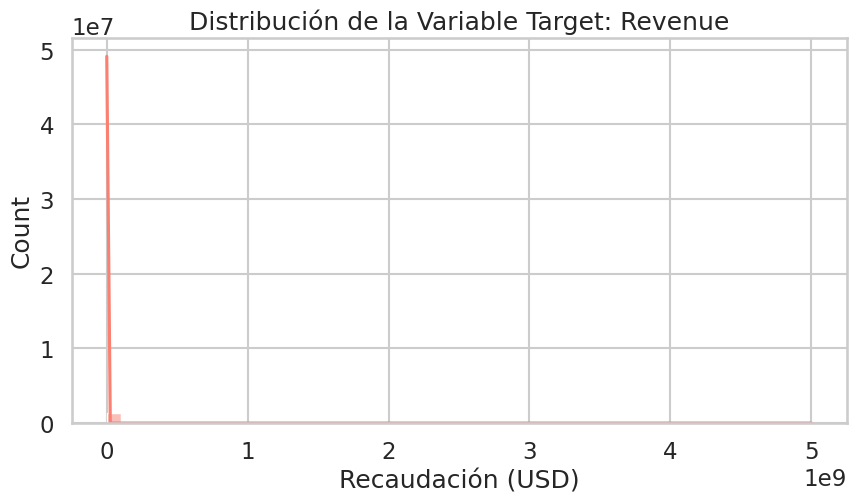

In [77]:
# Usamos histograma con KDE 
plt.figure(figsize=(10, 5))
sns.histplot(df['revenue'], bins=50, kde=True, color='salmon')
plt.title('Distribución de la Variable Target: Revenue')
plt.xlabel('Recaudación (USD)')
plt.show()

**Interpretación:** El histograma revela que la variable target tiene un sesgo extremo. El pico masivo en **0.0** indica que la mayoría de los registros no cuentan con datos de recaudación. 
* **Decisión:** Entrenar el modelo con estos ceros produciría predicciones erróneas. Como estrategia de preprocesamiento, se propone filtrar los registros con `revenue == 0` y aplicar una **transformación logarítmica** (visto en Clase 5) para normalizar la distribución.

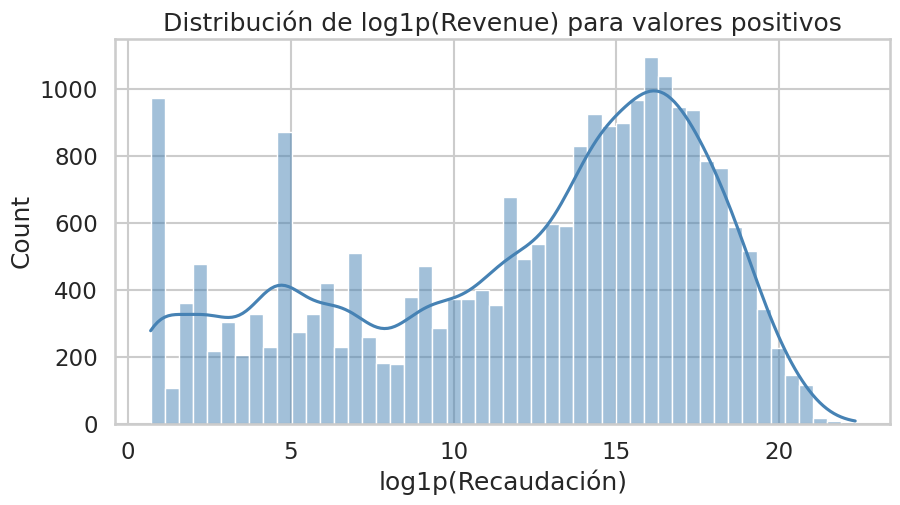

In [80]:
df_revenue_pos = df[df['revenue'] > 0].copy()

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df_revenue_pos['revenue']), bins=50, kde=True, color='steelblue')
plt.title('Distribución de log1p(Revenue) para valores positivos')
plt.xlabel('log1p(Recaudación)')
plt.show()


**Interpretación:** La distribución original de `revenue` presenta una gran concentración en cero, al restringir el análisis a `revenue > 0` y aplicar `log1p`, la distribución se vuelve considerablemente más estable.

**Decisión:** Para un futuro modelo supervisado, resulta razonable trabajar con `revenue > 0` y evaluar una transformación logarítmica de la variable target para reducir asimetría y sensibilidad a valores extremos.

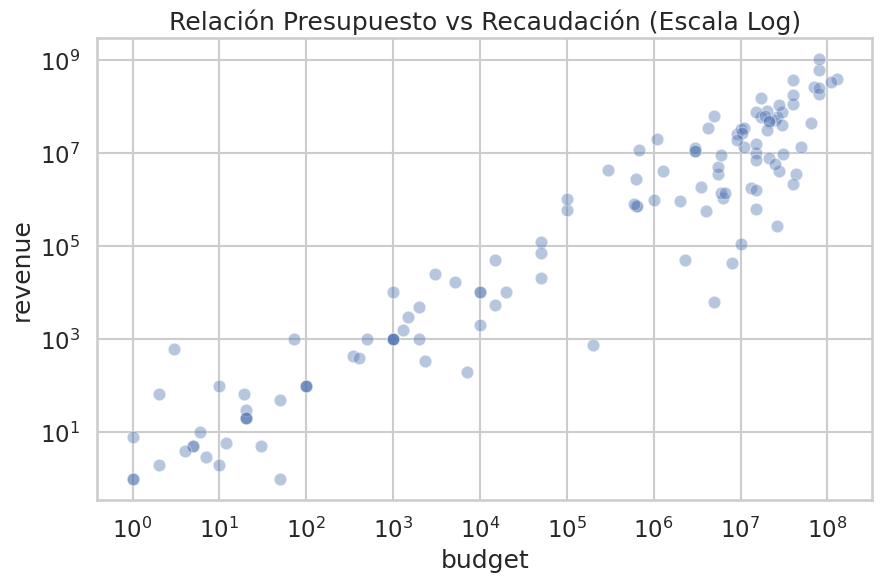

In [87]:
# Scatterplot con escala logarítmica 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='budget', y='revenue', alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.title('Relación Presupuesto vs Recaudación (Escala Log)')
plt.show()

En esta gráfica de dispersión con escala logarítmica, observamos una correlación positiva clara: a mayor presupuesto, mayor tendencia a una alta recaudación.
Hallazgo: Se observa una "pared" de datos en el valor $10^0$ (1 USD). Esto confirma que existen registros con valores mínimos que actúan como ruido.
Conclusión: El budget es un predictor sólido para nuestro modelo de regresión, pero requiere una limpieza de los valores mínimos antes del entrenamiento.

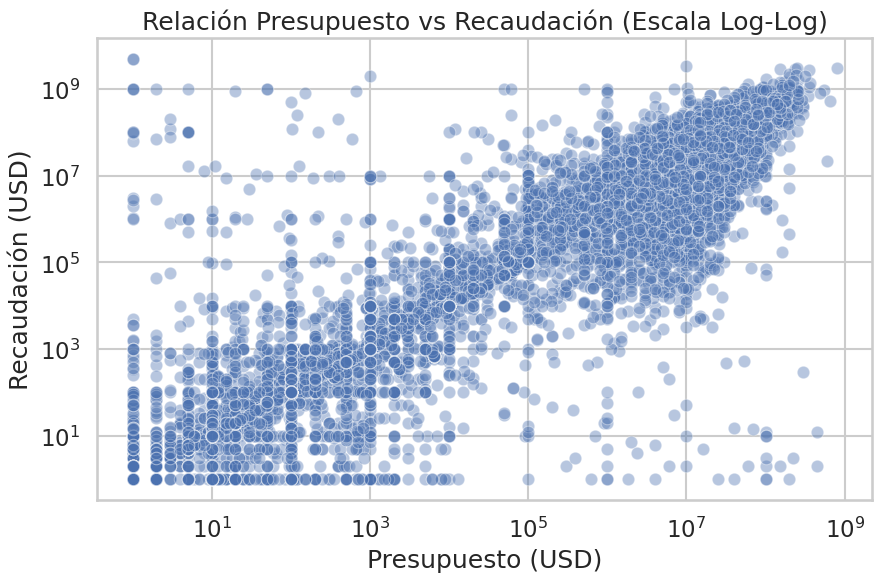

In [88]:
df_scatter = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()
n_scatter = min(10000, len(df_scatter))
df_scatter = df_scatter.sample(n=n_scatter, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_scatter, x='budget', y='revenue', alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.title('Relación Presupuesto vs Recaudación (Escala Log-Log)')
plt.xlabel('Presupuesto (USD)')
plt.ylabel('Recaudación (USD)')
plt.show()

**Interpretación:** Una vez removidos los valores no positivos, se observa una tendencia positiva entre `budget` y `revenue`: las películas con mayor presupuesto tienden, en términos generales, a recaudar más. No obstante, la dispersión sigue siendo amplia, lo que indica que el presupuesto no explica por sí solo el desempeño comercial.

**Conclusión:** `budget` aparece como una variable predictora relevante, aunque insuficiente por sí misma. Esto sugiere que el modelo debería complementarse con otras variables como `popularity`, `vote_count`, género, fecha de lanzamiento o idioma.

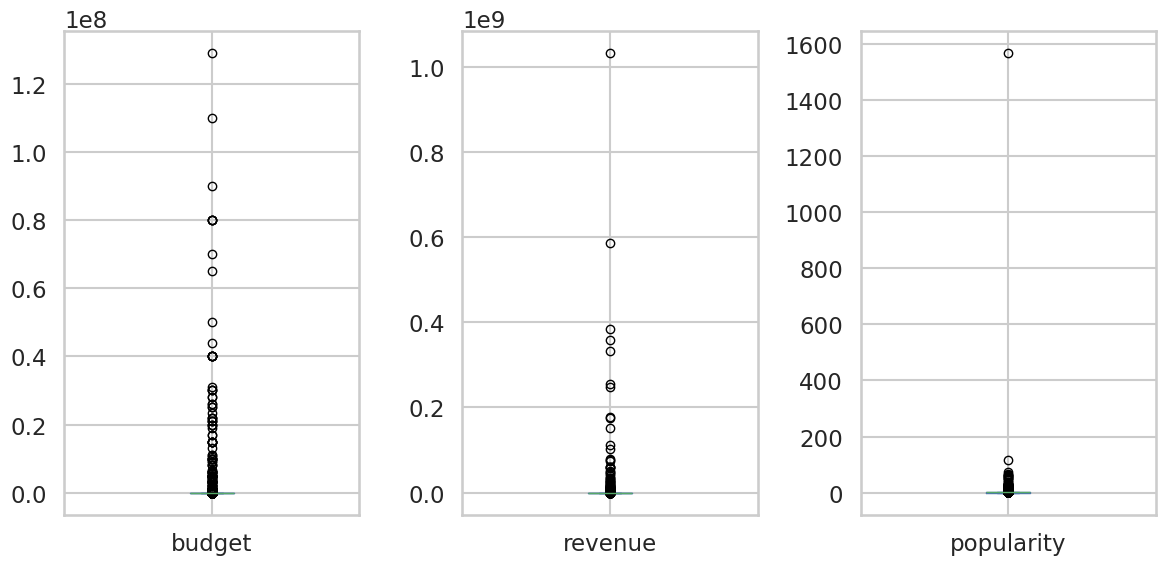

In [89]:
# Boxplot de variables clave
cols_to_plot = ['budget', 'revenue', 'popularity']
df_sample[cols_to_plot].plot(kind='box', subplots=True, layout=(1,3), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

**Interpretación:** Los boxplots evidencian una fuerte asimetría positiva y una gran presencia de valores extremos en `budget`, `revenue` y `popularity`.

**Conclusión:** Esto sugiere trabajar con estadísticas robustas y evaluar transformaciones logarítmicas o técnicas de tratamiento de outliers antes de utilizar estas variables en un modelo.

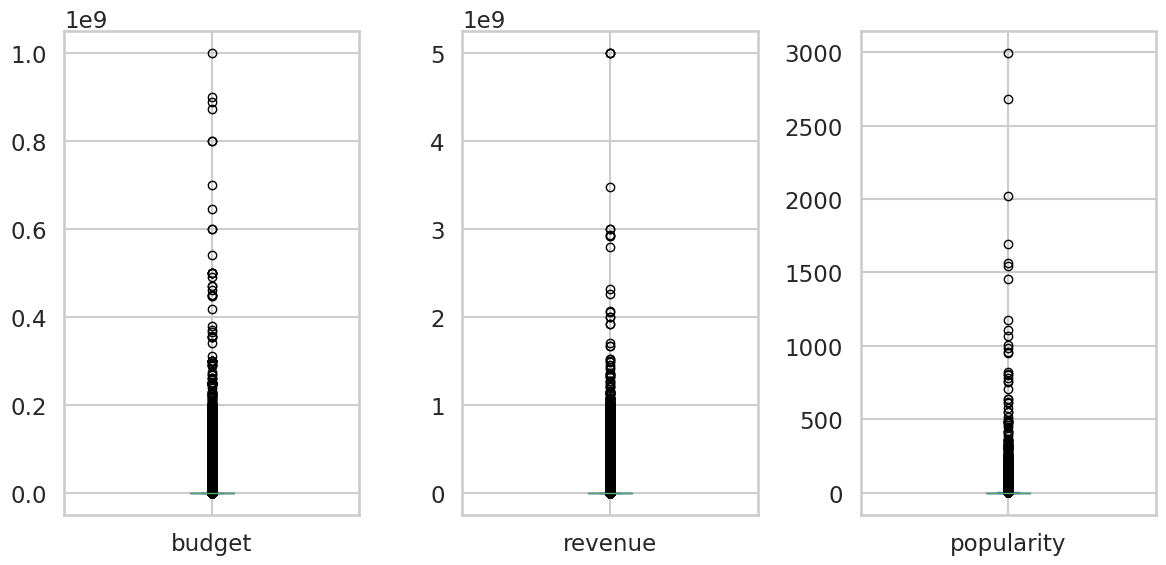

In [90]:
cols_to_plot = ['budget', 'revenue', 'popularity']
df[cols_to_plot].plot(kind='box', subplots=True, layout=(1,3), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

**Conclusión:** Los boxplots del dataset completo confirman una fuerte asimetría positiva y una gran cantidad de outliers en `budget`, `revenue` y `popularity`. Por ello, resulta conveniente apoyarse en estadísticas robustas y evaluar transformaciones logarítmicas o técnicas de tratamiento de valores extremos antes del modelado.

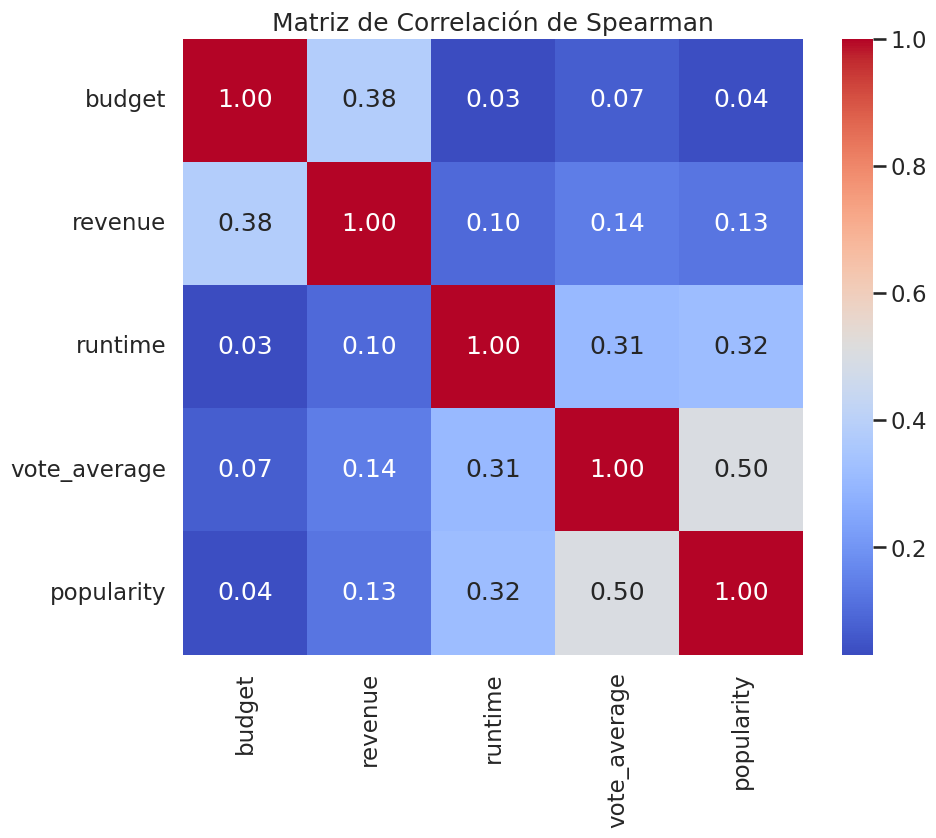

In [91]:
# Matriz de correlación de Spearman
corr_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'popularity']
corr_df = df[corr_cols].dropna()

plt.figure(figsize=(10, 8))
corr = corr_df.corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Spearman')
plt.show()

**Interpretación:** La matriz de Spearman muestra que `budget` mantiene una asociación positiva moderada-baja con `revenue` (**0.38**), por lo que podría ser una feature relevante para el modelado. En cambio, `popularity` y `vote_average` presentan relaciones más débiles con la target en esta etapa.

Entre las variables predictoras predominan correlaciones bajas, aunque `vote_average` y `popularity` exhiben una asociación más alta (**0.50**), lo que sugiere cierta superposición de información.

**Conclusión:** La matriz resulta útil como criterio preliminar de selección de features y sugiere continuar con la limpieza y transformación del dataset antes de definir el conjunto final de variables para un futuro modelo supervisado.

## Plantear un posible problema de ML supervisado a partir de los datos elegidos.


### Describir el problema de clasificación o de regresión.


### Definir la variable target.

## Preprocesamiento y limpieza del dataset (Valentin)


### Realizar una limpieza general del dataset, eliminando o corrigiendo datos inconsistentes o irrelevantes.


In [ ]:
df_prep = df.copy()

# --- Duplicados logicos (mismo id TMDB) ---
n_dup_filas = df_prep.duplicated(subset=["id"], keep=False).sum()
df_prep = df_prep.drop_duplicates(subset=["id"], keep="first")

# --- Fechas ---
df_prep["release_date"] = pd.to_datetime(df_prep["release_date"], errors="coerce")

# --- Reglas de consistencia para variables numéricas clave ---
va = pd.to_numeric(df_prep["vote_average"], errors="coerce")
df_prep.loc[(va < 0) | (va > 10), "vote_average"] = np.nan

for col in ("revenue", "budget"):
    s = pd.to_numeric(df_prep[col], errors="coerce")
    df_prep.loc[s < 0, col] = np.nan
    # En taquilla y presupuesto, 0 se trata como dato no informado (no como valor real).
    df_prep.loc[s == 0, col] = np.nan

rt = pd.to_numeric(df_prep["runtime"], errors="coerce")
df_prep.loc[rt <= 0, "runtime"] = np.nan

# --- Columnas irrelevantes para un primer modelo tabular (texto largo, paths, alta cardinalidad) ---
DROP_FOR_ML = [
    "backdrop_path", "homepage", "imdb_id", "overview",
    "poster_path", "tagline", "keywords",
    "production_companies", "production_countries",
    "spoken_languages", "genres",
    "title", "original_title",
]
df_model = df_prep.drop(
    columns=[c for c in DROP_FOR_ML if c in df_prep.columns], errors="ignore"
).copy()

# Variable temporal compacta (año de estreno); evita dejar datetime crudo en el bloque numerico.
df_model["release_year"] = df_model["release_date"].dt.year
df_model = df_model.drop(columns=["release_date"], errors="ignore")

print(f"Filas marcadas como duplicado por id (antes de deduplicar): {int(n_dup_filas)}")
print("Dimensiones df_model:", df_model.shape)
display(df_model.head(3))


Filas marcadas como duplicado por id (antes de deduplicar): 2113
Dimensiones df_model: (1401614, 13)


,id,vote_average,vote_count,status,revenue,runtime,adult,budget,original_language,popularity,year,quinquenio,release_year
0,27205,8.3640,34495,Released,"825,532,764.0000",148.0000,False,"160,000,000.0000",en,83.9520,"2,010.0000","2,010.0000","2,010.0000"
1,157336,8.4170,32571,Released,"701,729,206.0000",169.0000,False,"165,000,000.0000",en,140.2410,"2,014.0000","2,010.0000","2,014.0000"
2,155,8.5120,30619,Released,"1,004,558,444.0000",152.0000,False,"185,000,000.0000",en,130.6430,"2,008.0000","2,005.0000","2,008.0000"


### Realizar el split del dataset (ej: train y test).

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.2

# TODO: cuando se defina TARGET_COL, crear y_train/y_test con estos indices
# y sacqr TARGET_COL de X antes de entrenar.

# Bloque de columnas para preprocesar: todas salvo el identificador (no es feature).
FEATURE_COLS = [c for c in df_model.columns if c != "id"]
df_X = df_model[FEATURE_COLS]

# Partición train/test solo por índices (sin y). Orden: antes de imputar, outliers y escalado.
idx_train, idx_test = train_test_split(
    df_X.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
X_train = df_X.loc[idx_train]
X_test = df_X.loc[idx_test]

print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (1121291, 12) | Test: (280323, 12)


### Identificar y tratar los valores faltantes en el dataset.

In [ ]:
from sklearn.impute import SimpleImputer

# Tipos inferidos a partir del conjunto de entrenamiento (referencia para train y test)
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

X_train_imp = X_train.copy()
X_test_imp = X_test.copy()

# Imputacion univariada: mediana en variables numericas, moda en categoricas.
num_imputer = SimpleImputer(strategy="median")
X_train_imp[num_cols] = num_imputer.fit_transform(X_train_imp[num_cols])
X_test_imp[num_cols] = num_imputer.transform(X_test_imp[num_cols])

# Categoricas: moda en train. Supuestamente SimpleImputer(most_frequent) suele fallar con strings.
for c in cat_cols:
    m = X_train_imp[c].mode(dropna=True)
    fill = m.iloc[0] if len(m) > 0 else (False if pd.api.types.is_bool_dtype(X_train_imp[c]) else "")
    X_train_imp[c] = X_train_imp[c].fillna(fill)
    X_test_imp[c] = X_test_imp[c].fillna(fill)

print("Nulos restantes en X_train tras imputación:", int(X_train_imp.isna().sum().sum()))
display(X_train_imp.head(2))


Nulos restantes en X_train tras imputación: 0


,vote_average,vote_count,status,revenue,runtime,adult,budget,original_language,popularity,year,quinquenio,release_year
1279864,0.0000,0.0000,Released,"894,844.0000",115.0000,True,"3,200.0000",en,0.6000,"2,020.0000","2,020.0000","2,020.0000"
617610,0.0000,0.0000,Released,"894,844.0000",62.0000,False,"3,200.0000",en,0.0000,"2,012.0000","2,010.0000","2,012.0000"


### Detectar y manejar los outliers utilizando técnicas estadísticas o visuales apropiadas.

**Detección:** regla **IQR** con factor 1,5 (la misma idea que los bigotes del **boxplot**): se mide qué fracción de valores queda fuera del intervalo entre *Q1 − 1,5×IQR* y *Q3 + 1,5×IQR*.

**Tratamiento:** **winsorización** (*capping* por **percentiles** 1 y 99): los valores extremos se sustituyen por esos límites. Los percentiles se calculan **solo en train** y el mismo corte se aplica a test. Otras opciones habituales en este tipo de problemas son eliminar filas, transformar (por ejemplo **log** o raíz cuadrada), imputar a **media/mediana**, o agrupar en categorías; aquí se winsoriza para reducir el peso de las colas sin eliminar observaciones.


In [ ]:
# Deteccipn: IQR 1.5× (mismo criterio que los bigotes del boxplot).
# Tratamiento: winsorizacion = capping por percentiles 1 y 99 (train); mismo corte en test.


def pct_outliers_iqr(s: pd.Series) -> float:
    x = pd.to_numeric(s, errors="coerce").dropna()
    if len(x) < 4:
        return float("nan")
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return float(((x < lo) | (x > hi)).mean() * 100)


winsor_cols = [
    c for c in ["vote_count", "revenue", "runtime", "budget", "popularity"]
    if c in X_train_imp.columns
]

filas = []
for c in winsor_cols:
    lo, hi = X_train_imp[c].quantile([0.01, 0.99])
    filas.append(
        {
            "columna": c,
            "pct_outliers_IQR_train": pct_outliers_iqr(X_train_imp[c]),
            "p01_train": float(lo),
            "p99_train": float(hi),
        }
    )
display(pd.DataFrame(filas))

for c in winsor_cols:
    lo, hi = X_train_imp[c].quantile([0.01, 0.99])
    X_train_imp[c] = X_train_imp[c].clip(lower=lo, upper=hi)
    # Mismos límites aprendidos en train
    X_test_imp[c] = X_test_imp[c].clip(lower=lo, upper=hi)

# Comparacion visual rapida (train): cola pesada típica en `popularity`.
fig, ax = plt.subplots(figsize=(7, 4))
data_pop = [X_train["popularity"].dropna(), X_train_imp["popularity"]]
ax.boxplot(data_pop)
ax.set_xticklabels(["original (train)", "winsor 1–99% (train)"])
ax.set_title("Popularidad antes y después de winsorización (percentiles 1–99% en entrenamiento)")
ax.set_ylabel("popularity")
plt.show()


### Escalar y / o normalizar los features.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Estandarización (media 0, varianza 1) en el bloque numerico
scaler = StandardScaler()
X_train_ready = X_train_imp.copy()
X_test_ready = X_test_imp.copy()

X_train_ready[num_cols] = scaler.fit_transform(X_train_ready[num_cols])
X_test_ready[num_cols] = scaler.transform(X_test_ready[num_cols])

display(X_train_ready[num_cols].agg(["mean", "std"]).T.round(6))
print(
    "Train:", X_train_ready.shape, "| Test:", X_test_ready.shape,
)


## Feature engineering:

### Crear nuevos features en caso de ser necesario. Justificar.

### Aplicar técnicas de conversión de variables: codificación, discretización.

### Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación).

### Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección

## Reducción de dimensionalidad

### Evaluar relaciones entre variables y realizar una selección de features con los mecanismos vistos en clase (ej: filtros).

### Implementar técnicas de extracción de features (ej: PCA). Evaluar ventajas y desventajas de la reducción